# VEGO GLOBAL sales data analysis

## 1. data loading

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

internet_sales_copy = pd.read_excel("DATA/InternetSales.xlsx")
internet_sales = internet_sales_copy.copy()

customers = pd.read_json("DATA/customers.json")
products = pd.read_csv("DATA/Products.csv")
territories = pd.read_parquet("DATA/SalesTerritory.parquet")

print("Internet Sales:")
print(internet_sales.head())

print("\nCustomers:")
print(customers.head())

print("\nProducts:")
print(products.head())

print("\nSales Territories:")
print(territories.head())

Internet Sales:
   ProductKey  OrderDate   ShipDate  CustomerKey  PromotionKey  \
0         310 2010-12-29 2011-01-05        21768             1   
1         346 2010-12-29 2011-01-05        28389             1   
2         346 2010-12-29 2011-01-05        25863             1   
3         336 2010-12-29 2011-01-05        14501             1   
4         346 2010-12-29 2011-01-05        11003             1   

   SalesTerritoryKey SalesOrderNumber  SalesOrderLineNumber  RevisionNumber  \
0                  6          SO43697                     1               1   
1                  7          SO43698                     1               1   
2                  1          SO43699                     1               1   
3                  4          SO43700                     1               1   
4                  9          SO43701                     1               1   

   OrderQuantity  ...  UnitPriceDiscountPct  DiscountAmount  \
0              1  ...                     0      

## 2.Data cleaning & preparation

In [40]:
print("\nInternet Sales columns:")
print(internet_sales.columns.tolist())

print("\nProducts columns:")
print(products.columns.tolist())

print("\nTerritories columns:")
print(territories.columns.tolist())

print("\nInternet Sales data types:")
print(internet_sales.dtypes)

print("\nMissing values:")
print(internet_sales.isna().sum())

print("\nNumber of duplicate rows:")
print(internet_sales.duplicated().sum())

print("\nInternet Sales shape:")
print(internet_sales.shape)

internet_sales.columns = internet_sales.columns.astype(str)

internet_sales["OrderDate"] = pd.to_datetime(
    internet_sales["OrderDate"],
    errors="coerce"
)

internet_sales["ShipDate"] = pd.to_datetime(
    internet_sales["ShipDate"],
    errors="coerce"
)

integer_columns = [
    "ProductKey",
    "CustomerKey",
    "PromotionKey",
    "SalesTerritoryKey",
    "SalesOrderLineNumber",
    "RevisionNumber",
    "OrderQuantity"
]

for col in integer_columns:
    internet_sales[col] = pd.to_numeric(
        internet_sales[col],
        errors="coerce"
    ).astype("Int64")

amount_columns = [
    "UnitPrice",
    "ExtendedAmount",
    "DiscountAmount",
    "ProductStandardCost",
    "TotalProductCost"
]
for col in amount_columns:
    internet_sales[col] = pd.to_numeric(
        internet_sales[col],
        errors="coerce"
    )
currency_columns = [
    "29",
    "6",
    "98",
    "19",
    "36",
    "100"
]

print("\nCurrency columns:")
print(internet_sales[currency_columns].head())

print("\nRows containing currency amounts:")
print(internet_sales[currency_columns]
      .dropna(how="all").head()
)


Internet Sales columns:
['ProductKey', 'OrderDate', 'ShipDate', 'CustomerKey', 'PromotionKey', 'SalesTerritoryKey', 'SalesOrderNumber', 'SalesOrderLineNumber', 'RevisionNumber', 'OrderQuantity', 'UnitPrice', 'ExtendedAmount', 'UnitPriceDiscountPct', 'DiscountAmount', 'ProductStandardCost', 'TotalProductCost', 29, 6, 98, 19, 36, 100]

Products columns:
['ProductKey', 'ProductAlternateKey', 'ProductSubcategoryKey', 'WeightUnitMeasureCode', 'SizeUnitMeasureCode', 'EnglishProductName', 'SpanishProductName', 'FrenchProductName', 'StandardCost', 'FinishedGoodsFlag', 'Color', 'SafetyStockLevel', 'ReorderPoint', 'ListPrice', 'Size', 'SizeRange', 'Weight', 'DaysToManufacture', 'ProductLine', 'DealerPrice', 'Class', 'Style', 'ModelName', 'EnglishDescription', 'FrenchDescription', 'ChineseDescription', 'ArabicDescription', 'HebrewDescription', 'ThaiDescription', 'GermanDescription', 'JapaneseDescription', 'TurkishDescription', 'StartDate', 'EndDate', 'Status']

Territories columns:
['SalesTerrit

 ## .3 currency mapping & unpivoting 

In [41]:
 
id_columns = [
    col for col in internet_sales.columns
    if col not in currency_columns
]

internet_sales = internet_sales.melt(
    id_vars=id_columns,
    value_vars=currency_columns,
    var_name="CurrencyKey",
    value_name="SalesAmount"
)
internet_sales["CurrencyKey"] = pd.to_numeric(
    internet_sales["CurrencyKey"],
    errors="coerce"
).astype("Int64")

internet_sales = internet_sales.dropna(
    subset=["SalesAmount"]
).copy()

currency_mapping = {
    6: "AUD",
    19: "CAD",
    29: "DEM",
    36: "EUR",
    98: "GBP",
    100: "USD"
}

internet_sales["Currency"] = internet_sales["CurrencyKey"].map(currency_map)

print("\nCurrency mapping:")
print(
    internet_sales[["CurrencyKey", "Currency"]]
    .drop_duplicates()
    .sort_values("CurrencyKey")
)

print("\nDataset after unpivoting:")
print(internet_sales.head())
print("\nNew shape:")
print(internet_sales.shape)


Currency mapping:
        CurrencyKey Currency
60402             6      AUD
181194           19      CAD
15               29      DEM
120807           98      GBP
301992          100      USD

Dataset after unpivoting:
    ProductKey  OrderDate   ShipDate  CustomerKey  PromotionKey  \
15         311 2011-01-01 2011-01-08        13513             1   
23         311 2011-01-03 2011-01-10        13264             1   
28         311 2011-01-05 2011-01-12        13258             1   
40         311 2011-01-08 2011-01-15        13261             1   
55         311 2011-01-11 2011-01-18        13265             1   

    SalesTerritoryKey SalesOrderNumber  SalesOrderLineNumber  RevisionNumber  \
15                  8          SO43712                     1               1   
23                  8          SO43720                     1               1   
28                  8          SO43725                     1               1   
40                  8          SO43737                   

## .4 Data integration

In [42]:

internet_sales = internet_sales.merge(
    territories,
    on="SalesTerritoryKey",
    how="left"
)
internet_sales.shape
customers.columns
products.columns
internet_sales = internet_sales.merge(
    customers,
    on="CustomerKey",
    how="left"
)
internet_sales = internet_sales.merge(
    products,
    on="ProductKey",
    how="left"
)
print("\nMerged dataset shape:")
print(internet_sales.shape)


print("\nMerged dataset:")
print(internet_sales.head())



Merged dataset shape:
(60339, 85)

Merged dataset:
   ProductKey  OrderDate   ShipDate  CustomerKey  PromotionKey  \
0         311 2011-01-01 2011-01-08        13513             1   
1         311 2011-01-03 2011-01-10        13264             1   
2         311 2011-01-05 2011-01-12        13258             1   
3         311 2011-01-08 2011-01-15        13261             1   
4         311 2011-01-11 2011-01-18        13265             1   

   SalesTerritoryKey SalesOrderNumber  SalesOrderLineNumber  RevisionNumber  \
0                  8          SO43712                     1               1   
1                  8          SO43720                     1               1   
2                  8          SO43725                     1               1   
3                  8          SO43737                     1               1   
4                  8          SO43752                     1               1   

   OrderQuantity  ...                                 ChineseDescription  \


## 5.Data analysis

In [43]:

sales_by_currency = (
    internet_sales.groupby("Currency")["SalesAmount"]
    .sum().
    sort_values(ascending=False)
) 

sales_by_territory = (
    internet_sales.groupby("SalesTerritoryGroup")["SalesAmount"]
    .sum().sort_values(ascending=False)
)

internet_sales["Year"] = internet_sales["OrderDate"].dt.year

sales_by_year = (
    internet_sales.groupby("Year")["SalesAmount"]
    .sum().
    sort_index()
)
 
sales_by_distance = (
    internet_sales.groupby("CommuteDistance")["SalesAmount"]
    .sum()
    .sort_values(ascending=False)
)
sales_by_gender = (
    internet_sales.groupby("Gender")["SalesAmount"]
    .sum()
    .sort_values(ascending=False)
)
sales_by_subcategory = (
    internet_sales.groupby("ProductSubcategoryKey")["SalesAmount"]
    .sum()
    .sort_values(ascending=False)
)
sales_by_status = (
    internet_sales.groupby("Status")["ExtendedAmount"]
    .sum()
    .sort_values(ascending=False)
)
monthly_sales = (
    internet_sales.groupby(
        internet_sales["OrderDate"].dt.to_period("M")
    )["ExtendedAmount"]
    .sum()
)
top_products = (
    internet_sales.groupby("EnglishProductName")["SalesAmount"]
    .sum().
    sort_values(ascending=False).
    head(10)
)
top_products

EnglishProductName
Mountain-200 Black, 46     1.373470e+06
Mountain-200 Black, 42     1.363142e+06
Mountain-200 Silver, 38    1.339463e+06
Mountain-200 Silver, 46    1.301100e+06
Mountain-200 Black, 38     1.294866e+06
Mountain-200 Silver, 42    1.257435e+06
Road-150 Red, 62           1.187986e+06
Road-150 Red, 48           1.159359e+06
Road-150 Red, 52           1.055590e+06
Road-150 Red, 56           1.037698e+06
Name: SalesAmount, dtype: float64

## 6.Visualization

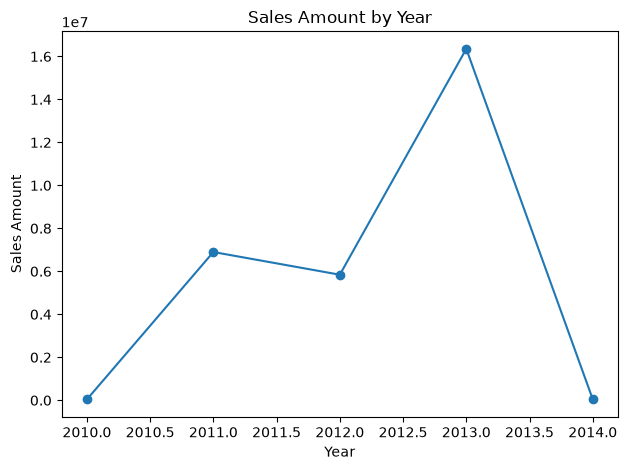

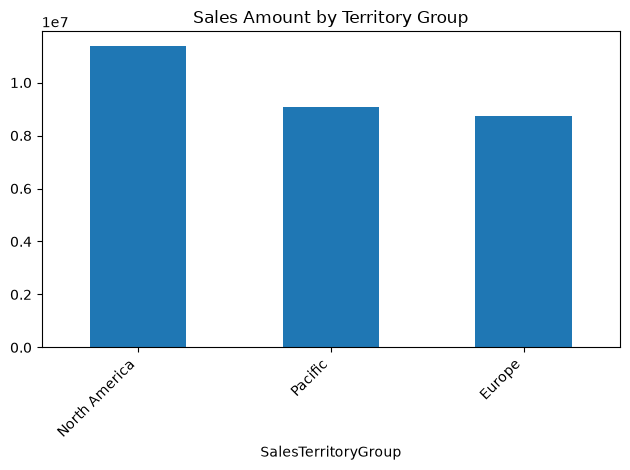

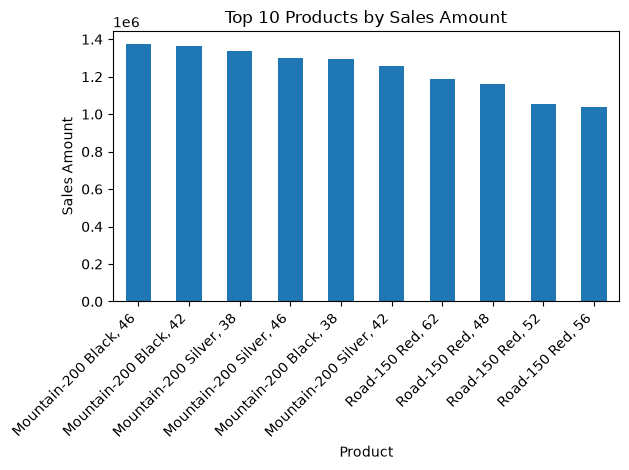

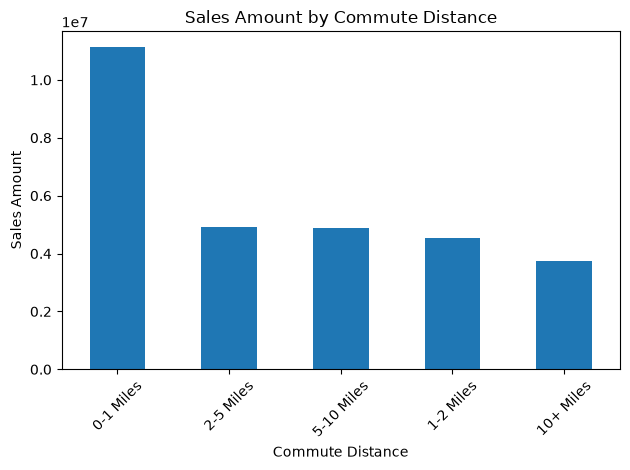

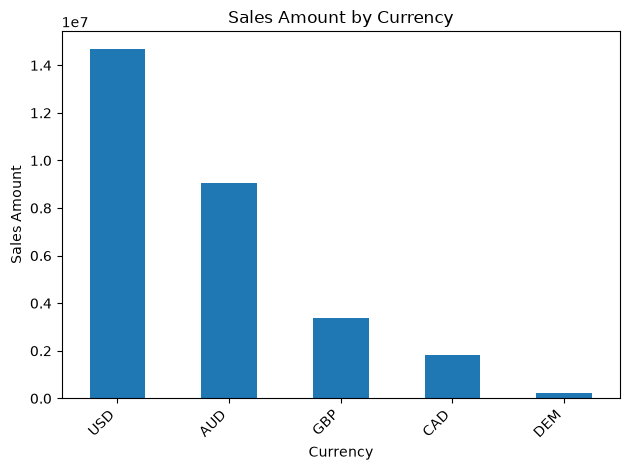

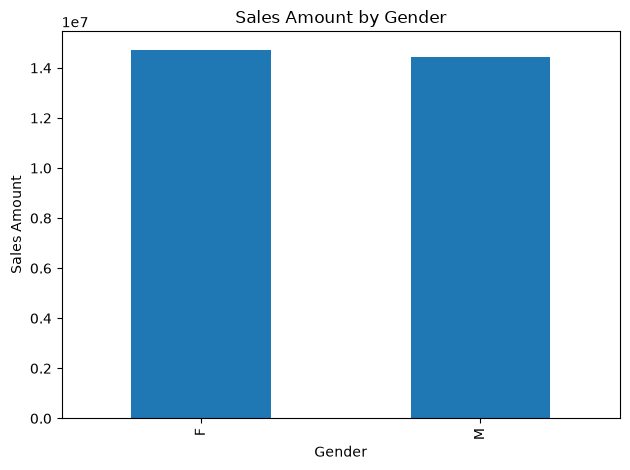

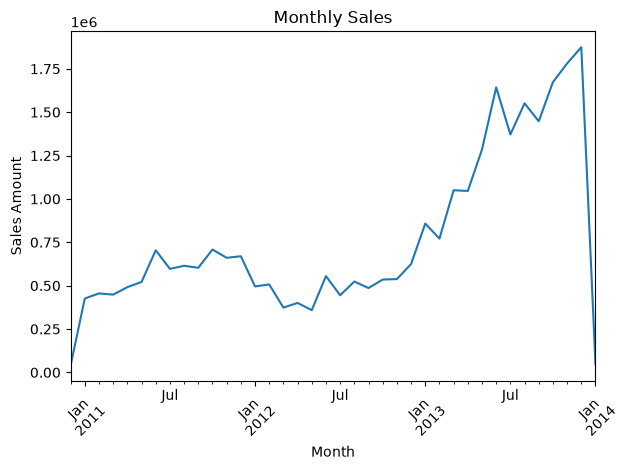

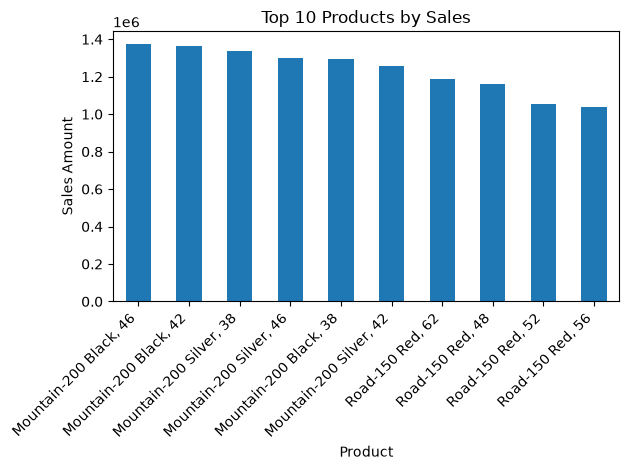

In [46]:
 
sales_by_year.plot(
    kind="line",
    marker="o",
    title="Sales Amount by Year",
    xlabel="Year",
    ylabel="Sales Amount"
) 
plt.tight_layout() 
plt.show()

sales_by_territory.plot(
    kind="bar",
    title="Sales Amount by Territory Group"
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
 
 
sales_by_distance.plot(
    kind="bar",
    title="Sales Amount by Commute Distance",
    xlabel="Commute Distance",
    ylabel="Sales Amount"
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

sales_by_currency.plot(
    kind="bar",
    title="Sales Amount by Currency",
    xlabel="Currency",
    ylabel="Sales Amount"
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

sales_by_gender.plot(
    kind="bar",
    title="Sales Amount by Gender",
    xlabel="Gender",
    ylabel="Sales Amount"
)
plt.tight_layout()
plt.show()

monthly_sales.plot(
    kind="line",
    title="Monthly Sales",
    xlabel="Month",
    ylabel="Sales Amount",
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

top_products.plot(
    kind="bar",
    title="Top 10 Products by Sales",
    xlabel="Product",
    ylabel="Sales Amount",
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## .conclusion 

Conclusion
The analysis of VEGO GLOBAL's sales data provided useful insights into sales performance and customer behavior. North America generated the highest sales among the territory groups, followed by the Pacific and Europe. Sales increased significantly over the years and reached their highest level in 2013. The analysis also showed that Mountain-200 and Road-150 product variants were among the top-selling products. In terms of customer behavior, customers living 0–1 miles from the business generated the highest sales.
These insights can help VEGO GLOBAL improve sales strategies, identify high-performing products and markets, and better understand customer behavior. However, sales amounts across different currencies should not be directly compared without applying exchange rates.